# Protocols of communication in quantum networks

## Libraries used in the notebook

The Python implementation of the various protocols is in the folder "Library"

The C implementation can be found in the folder "Code"

In [1]:
import networkx as nx
import numpy as np
import sys
from pylab import *
%matplotlib inline
import subprocess
import shlex
import pickle
from Library import quantum_functions

The code is used on the well-known social network dataset "Zackary's Karate Club." The list of edges of this network is provided with the code. Please note that the C implementation requires nodes with numerical labels starting from 1. For this reason, we first create a list of edges where nodes of the graph are relabeled. 

The parameter "PERC_TYPE" is used to decide the percolation protocol to use, i.e., PERC_TYPE = 1 indicate QPA, whereas PERC_TYPE = 2 denotes CPA. $W \in [1/2, 1]$  is the Schmidt coefficient of the individual edges.

In [2]:
netfile = 'NetworkData/karate_club.net'
###
H = nx.karate_club_graph()
mapping = {}
for n in H.nodes():
    mapping[n] = n + 1
H = nx.relabel_nodes(H, mapping)
nx.write_edgelist(H, netfile, data=False)

In [3]:
PERC_TYPE = 1 
W = 0.7 

In [4]:
G = nx.read_edgelist(netfile)

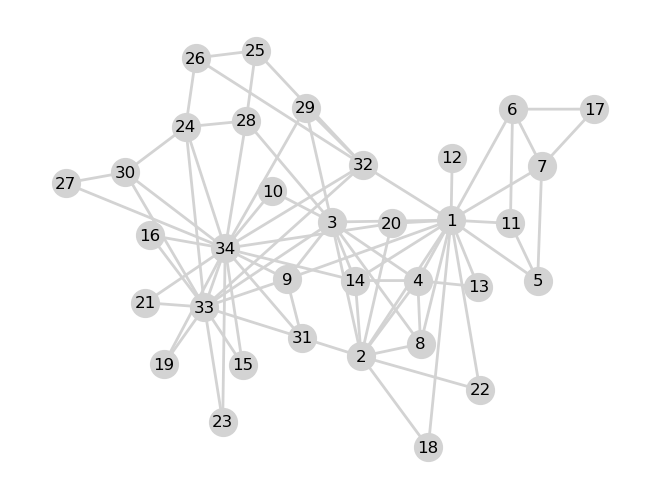

In [5]:
std_color = '#D3D3D3'
# color_pair = '#5BA8FF'
color_pair = 'red'
color_rep = 'blue'
node_size = 400



try:
    # pos = nx.kamada_kawai_layout(G) 
    # pos = nx.spring_layout(G)
    # pos = nx.nx_pydot.graphviz_layout(G, prog='fdp')
    pos = nx.drawing.nx_agraph.graphviz_layout(G, prog='sfdp', args='-Goverlap=prism -GK=1 -Goverlap_scaling=0.7  -Grepulsiveforce=0.5')
    with open('nodes_positions.pckl', 'wb') as file:
        pickle.dump(pos, file)
except:
    with open('nodes_positions.pckl', 'rb') as file:
        pos = pickle.load(file)


nx.draw(G, pos, with_labels=True, node_color=std_color, node_size=node_size, font_family ='sans-serif',  font_size=12, font_weight='regular', edge_color=std_color, width=2)
# 
# plt.savefig('karate_A.pdf')

## QPA protocol for a single pair of nodes

The following code generates list of paths to establish a quantum channel between a given pair of nodes $s$ and $t$ in the network according to the hxQPA protocol. The parameter max_distance = x = 0, 1, 2 serves to define the neighborhood of the nodes $s$ and $t$ when applying the heterogenous version of the hxQPA protocol. When max_distance = 0, the protocol is equivalent to standard QPA.

In [11]:
print (G)

pair = ['17', '27']



max_distance = 0
removed_edges, scores, nodes = quantum_functions.pair_entanglement_refined (G, pair, W, PERC_TYPE, max_distance)

print(removed_edges)
print(scores)

quantum_functions.restore_edges_refined (G, removed_edges)

print (G)

#################
ent, nr_edges = quantum_functions.estimate_entanglement_result_refined ([ [pair[0], pair[1]], removed_edges, scores, nodes], PERC_TYPE)
print('#Entanglement ', ent)
print('#Number of edges used ', nr_edges)

Graph with 34 nodes and 78 edges
{1: {0: [['17', '7'], ['7', '1'], ['1', '20'], ['20', '34'], ['34', '27']], 1: [['17', '6'], ['6', '1'], ['1', '32'], ['32', '34'], ['34', '30'], ['30', '27']]}}
{1: {0: np.float64(0.8813751622746294), 1: np.float64(0.9027101837500511)}}
Graph with 34 nodes and 78 edges
#Entanglement  0.40874733062067636
#Number of edges used  11


A different color is used to represent the edges in each of the identified path. Source and target nodes are displayed with a different color from the other nodes.

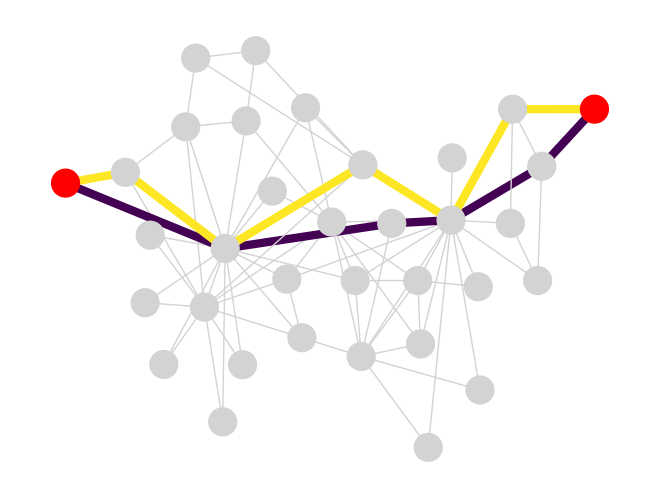

In [12]:
for u, v in G.edges:
    G[u][v]['color']  = std_color
    G[u][v]['width']  = 1
for node in G:
    G.nodes[node]['color'] = std_color
    
#####################


#####################
cmap = matplotlib.colormaps['viridis']
E = 0
for q in removed_edges:
    for r in removed_edges[q]:
        E += 1

values = np.linspace(0, 1, E) 
colors_paths = cmap(values)
dict_colors_paths = {}
for e in range(0, len(colors_paths)):
    dict_colors_paths[e] = colors_paths[e]
#####################

e = 0
for q in removed_edges:
    for r in removed_edges[q]:
        # color = (np.round(np.random.rand(),1), np.round(np.random.rand(),1), np.round(np.random.rand(),1))
        color = dict_colors_paths[e]
        e += 1
        for u, v in removed_edges[q][r]:
            G[u][v]['color'] = color
            G[u][v]['width'] = 6
#####################

G.nodes[pair[0]]['color'] = color_pair
G.nodes[pair[1]]['color'] = color_pair
##########################
colors = [G[u][v]['color'] for u,v in G.edges]
width = [G[u][v]['width'] for u,v in G.edges]
node_colors = [G.nodes[node]['color'] for node in G.nodes()]



# nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_size, font_size=12, font_weight='bold', edge_color=colors, width=width)
nx.draw(G, pos, with_labels=False, node_color=node_colors, node_size=node_size, font_size=12, font_weight='bold', edge_color=colors, width=width)


# plt.savefig('karate_B.pdf')

# h1QPA protocol for a single pair of nodes

Same as above, but for the h1QPA protocol. This is simply obtained by setting max_distance = 1. Paths are identified between the source node $s$ and its repeater $r_s$, the target node $t$ and its repeater $r_t$, and the two repeaters $r_s$ and $r_t$.

In [13]:
print (G)

pair = ['17', '27']


max_distance = 1
removed_edges, scores, nodes = quantum_functions.pair_entanglement_refined (G, pair, W, PERC_TYPE, max_distance)

print(removed_edges)
print(scores)
print(nodes)

## restore used edges
quantum_functions.restore_edges_refined (G, removed_edges)

print (G)

ent, nr_edges = quantum_functions.estimate_entanglement_result_refined ([ [pair[0], pair[1]] , removed_edges, scores, nodes], PERC_TYPE)
print('#Entanglement ', ent)
print('#Number of edges used ', nr_edges)

Graph with 34 nodes and 78 edges
{1: {0: [['17', '7']], 1: [['17', '6'], ['6', '7']]}, 3: {0: [['34', '27']], 1: [['34', '30'], ['30', '27']]}, 2: {0: [['7', '1'], ['1', '32'], ['32', '34']], 1: [['7', '5'], ['5', '1'], ['1', '9'], ['9', '34']]}}
{1: {0: np.float64(0.6999999999999998), 1: np.float64(0.7712931993250105)}, 3: {0: np.float64(0.6999999999999998), 1: np.float64(0.7712931993250105)}, 2: {0: np.float64(0.8190987308028659), 1: np.float64(0.854305179188789)}}
['17', '7', '34', '27']
Graph with 34 nodes and 78 edges
#Entanglement  0.5873396144337528
#Number of edges used  13


A different color is used to represent the edges in each of the identified path. Source and target nodes, as well as their repeaters, are displayed with a different color from the other nodes

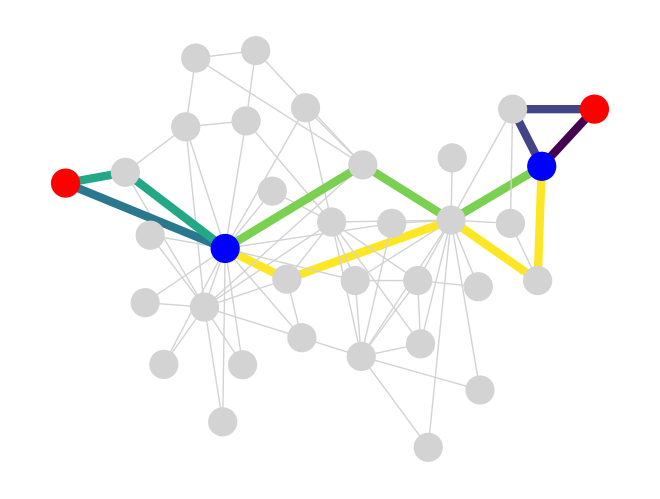

In [14]:
for u, v in G.edges:
    G[u][v]['color']  = std_color
    G[u][v]['width']  = 1
for node in G:
    G.nodes[node]['color'] = std_color
    
#####################

#####################
cmap = matplotlib.colormaps['viridis']
E = 0
for q in removed_edges:
    for r in removed_edges[q]:
        E += 1

values = np.linspace(0, 1, E) 
colors_paths = cmap(values)
dict_colors_paths = {}
for e in range(0, len(colors_paths)):
    dict_colors_paths[e] = colors_paths[e]
#####################

e = 0
for q in removed_edges:
    for r in removed_edges[q]:
        # color = (np.round(np.random.rand(),1), np.round(np.random.rand(),1), np.round(np.random.rand(),1))
        color = dict_colors_paths[e]
        e += 1
        for u, v in removed_edges[q][r]:
            G[u][v]['color'] = color
            G[u][v]['width'] = 6
#####################

G.nodes[pair[0]]['color'] = color_pair
G.nodes[pair[1]]['color'] = color_pair

G.nodes[nodes[1]]['color'] = color_rep
G.nodes[nodes[2]]['color'] = color_rep
##########################
colors = [G[u][v]['color'] for u,v in G.edges]
width = [G[u][v]['width'] for u,v in G.edges]
node_colors = [G.nodes[node]['color'] for node in G.nodes()]


# nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_size, font_size=12, font_weight='bold', edge_color=colors, width=width)
nx.draw(G, pos, with_labels=False, node_color=node_colors, node_size=node_size, font_size=12, font_weight='bold', edge_color=colors, width=width)

# plt.savefig('karate_C.pdf')

# h2QPA protocol for a single pair of nodes

Same as above, but for the h2QPA protocol. This is simply obtained by setting max_distance = 2. Paths are identified between the source node $s$ and its repeater $r_s$, the target node $t$ and its repeater $r_t$, and the two repeaters $r_s$ and $r_t$.

In [15]:
print (G)

pair = ['17', '27']


max_distance = 2
removed_edges, scores, nodes = quantum_functions.pair_entanglement_refined (G, pair, W, PERC_TYPE, max_distance)

print(removed_edges)
print(scores)
print(nodes)

## restore used edges
quantum_functions.restore_edges_refined (G, removed_edges)

print (G)

ent, nr_edges = quantum_functions.estimate_entanglement_result_refined ([ [pair[0], pair[1]] , removed_edges, scores, nodes], PERC_TYPE)
print('#Entanglement ', ent)
print('#Number of edges used ', nr_edges)

Graph with 34 nodes and 78 edges
{1: {0: [['17', '7'], ['7', '1']], 1: [['17', '6'], ['6', '1']]}, 3: {0: [['34', '27']], 1: [['34', '30'], ['30', '27']]}, 2: {0: [['1', '14'], ['14', '34']], 1: [['1', '32'], ['32', '34']], 2: [['1', '20'], ['20', '34']]}}
{1: {0: np.float64(0.7712931993250105), 1: np.float64(0.7712931993250105)}, 3: {0: np.float64(0.6999999999999998), 1: np.float64(0.7712931993250105)}, 2: {0: np.float64(0.7712931993250105), 1: np.float64(0.7712931993250105), 2: np.float64(0.7712931993250105)}}
['17', '1', '34', '27']
Graph with 34 nodes and 78 edges
#Entanglement  0.7946730417472099
#Number of edges used  13


A different color is used to represent the edges in each of the identified path. Source and target nodes, as well as their repeaters, are displayed with a different color from the other nodes

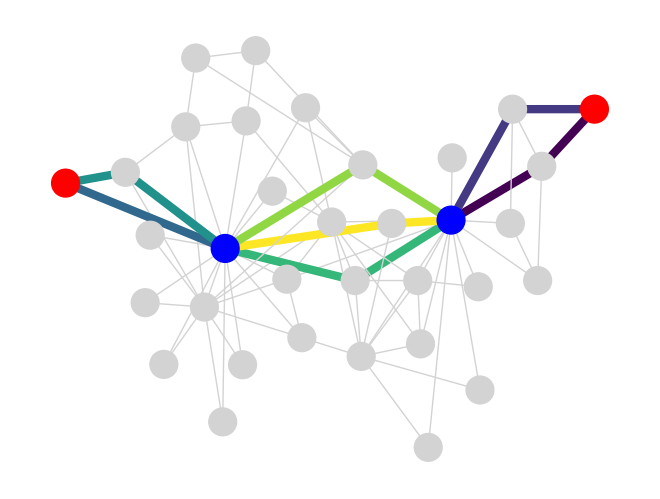

In [16]:
for u, v in G.edges:
    G[u][v]['color']  = std_color
    G[u][v]['width']  = 1
for node in G:
    G.nodes[node]['color'] = std_color
    
#####################

#####################
cmap = matplotlib.colormaps['viridis']
E = 0
for q in removed_edges:
    for r in removed_edges[q]:
        E += 1

values = np.linspace(0, 1, E) 
colors_paths = cmap(values)
dict_colors_paths = {}
for e in range(0, len(colors_paths)):
    dict_colors_paths[e] = colors_paths[e]
#####################

e = 0
for q in removed_edges:
    for r in removed_edges[q]:
        # color = (np.round(np.random.rand(),1), np.round(np.random.rand(),1), np.round(np.random.rand(),1))
        color = dict_colors_paths[e]
        e += 1
        for u, v in removed_edges[q][r]:
            G[u][v]['color'] = color
            G[u][v]['width'] = 6
#####################

G.nodes[pair[0]]['color'] = color_pair
G.nodes[pair[1]]['color'] = color_pair

G.nodes[nodes[1]]['color'] = color_rep
G.nodes[nodes[2]]['color'] = color_rep
##########################
colors = [G[u][v]['color'] for u,v in G.edges]
width = [G[u][v]['width'] for u,v in G.edges]
node_colors = [G.nodes[node]['color'] for node in G.nodes()]

# nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_size, font_size=12, font_weight='bold', edge_color=colors, width=width)
nx.draw(G, pos, with_labels=False, node_color=node_colors, node_size=node_size, font_size=12, font_weight='bold', edge_color=colors, width=width)

# plt.savefig('karate_D.pdf')

## CPA protocol for a single pair of nodes

Same as above, but for the CPA protocol. This is pbtained by setting the parameter PERC_TYPE = 2.

In [17]:
print (G)

pair = ['17', '27']

PERC_TYPE = 2
max_distance = 0
removed_edges, scores, nodes = quantum_functions.pair_entanglement_refined (G, pair, W, PERC_TYPE, max_distance)

print(removed_edges)
print(scores)

quantum_functions.restore_edges_refined (G, removed_edges)

print (G)

#################
ent, nr_edges = quantum_functions.estimate_entanglement_result_refined ([ [pair[0], pair[1]], removed_edges, scores, nodes], PERC_TYPE)
print('#Entanglement ', ent)
print('#Number of edges used ', nr_edges)

Graph with 34 nodes and 78 edges
{1: {0: [['17', '7'], ['7', '1'], ['1', '14'], ['14', '34'], ['34', '27']], 1: [['17', '6'], ['6', '1'], ['1', '32'], ['32', '34'], ['34', '30'], ['30', '27']]}}
{1: {0: np.float64(0.07776000000000007), 1: np.float64(0.04665600000000005)}}
Graph with 34 nodes and 78 edges
#Entanglement  0.12078802944000011
#Number of edges used  11


A different color is used to represent the edges in each of the identified path. Source and target nodes are displayed with a different color from the other nodes.

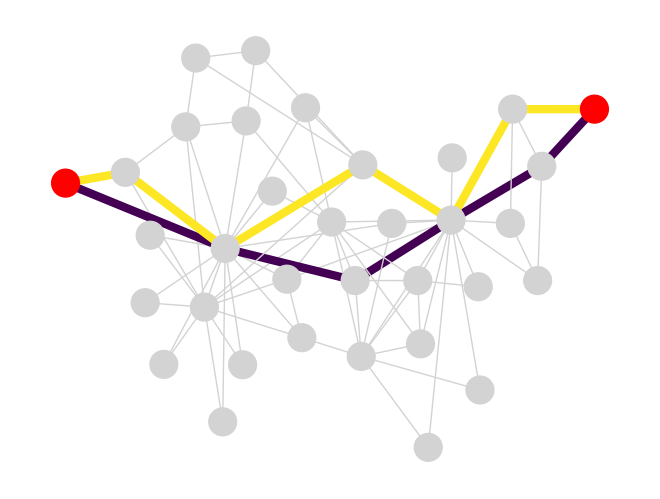

In [18]:
for u, v in G.edges:
    G[u][v]['color']  = std_color
    G[u][v]['width']  = 1
for node in G:
    G.nodes[node]['color'] = std_color
    
#####################


#####################
cmap = matplotlib.colormaps['viridis']
E = 0
for q in removed_edges:
    for r in removed_edges[q]:
        E += 1

values = np.linspace(0, 1, E) 
colors_paths = cmap(values)
dict_colors_paths = {}
for e in range(0, len(colors_paths)):
    dict_colors_paths[e] = colors_paths[e]
#####################

e = 0
for q in removed_edges:
    for r in removed_edges[q]:
        # color = (np.round(np.random.rand(),1), np.round(np.random.rand(),1), np.round(np.random.rand(),1))
        color = dict_colors_paths[e]
        e += 1
        for u, v in removed_edges[q][r]:
            G[u][v]['color'] = color
            G[u][v]['width'] = 6
#####################

G.nodes[pair[0]]['color'] = color_pair
G.nodes[pair[1]]['color'] = color_pair
##########################
colors = [G[u][v]['color'] for u,v in G.edges]
width = [G[u][v]['width'] for u,v in G.edges]
node_colors = [G.nodes[node]['color'] for node in G.nodes()]



# nx.draw(G, pos, with_labels=True, node_color=node_colors, node_size=node_size, font_size=12, font_weight='bold', edge_color=colors, width=width)
nx.draw(G, pos, with_labels=False, node_color=node_colors, node_size=node_size, font_size=12, font_weight='bold', edge_color=colors, width=width)


# plt.savefig('karate_B.pdf')

# Phase diagram

We display here the phase diagrams for the various communication protocols generated using our Python implementation. The phase diagram is approximated relying on $P$ sampled pairs of source and target nodes.

In [19]:
data_h2qep, data_hqep, data_qep, data_cep = [], [], [], []

P = 1000
for ent in np.linspace(0.01, 0.99, 20):

    w = 1.0 - 0.5* ent

    results_h2qep = quantum_functions.quantum_percolation_refined (G, P, w, 1, 2)
    summary_h2qep = quantum_functions.summarize_results_refined (results_h2qep, 1)
    # print (summary_h2qep)
    data_h2qep.append([ent, summary_h2qep[0]])
    
    results_hqep = quantum_functions.quantum_percolation_refined (G, P, w, 1, 1)
    summary_hqep = quantum_functions.summarize_results_refined (results_hqep, 1)
    # print (summary_hqep)
    data_hqep.append([ent, summary_hqep[0]])
    
    results_qep = quantum_functions.quantum_percolation_refined (G, P, w, 1, 0)
    summary_qep = quantum_functions.summarize_results_refined (results_qep, 1)
    # print (summary_qep)
    data_qep.append([ent, summary_qep[0]])

    results_cep = quantum_functions.quantum_percolation_refined (G, P, w, 2, 0)
    summary_cep = quantum_functions.summarize_results_refined (results_cep, 2)
    # print (summary_cep)
    data_cep.append([ent, summary_cep[0]])

data_h2qep = np.array(data_h2qep)
data_hqep = np.array(data_hqep)
data_qep = np.array(data_qep)
data_cep = np.array(data_cep)

In [20]:
data_qep_cep = quantum_functions.quantum_percolation_equal_weights (G, P)

##############################
formatted_data_qep_cep = []
for q in data_qep_cep:
    formatted_data_qep_cep.append(data_qep_cep[q])
##############################

data_qep_fast = quantum_functions.generate_diagram (formatted_data_qep_cep, 1, 0.01, 0.99, 20)
data_cep_fast = quantum_functions.generate_diagram (formatted_data_qep_cep, 2, 0.01, 0.99, 20)

Estimate the area under the curve (AUC) for each of the cosidered protocols.

In [21]:
print ('AUC h2QPA ', quantum_functions.measure_auc_entanglement(data_h2qep))
print ('AUC hQPA ', quantum_functions.measure_auc_entanglement(data_hqep))
print ('AUC QPA ', quantum_functions.measure_auc_entanglement(data_qep))
print ('AUC CPA ', quantum_functions.measure_auc_entanglement(data_cep))
print ('AUC QPA (fast alg.) ', quantum_functions.measure_auc_entanglement(data_qep_fast))
print ('AUC CPA (fast alg.) ', quantum_functions.measure_auc_entanglement(data_cep_fast))

AUC h2QPA  0.5982383280901216
AUC hQPA  0.6111619420774042
AUC QPA  0.5501992537762761
AUC CPA  0.4228235866474851
AUC QPA (fast alg.)  0.5565024208630647
AUC CPA (fast alg.)  0.42992491439458735


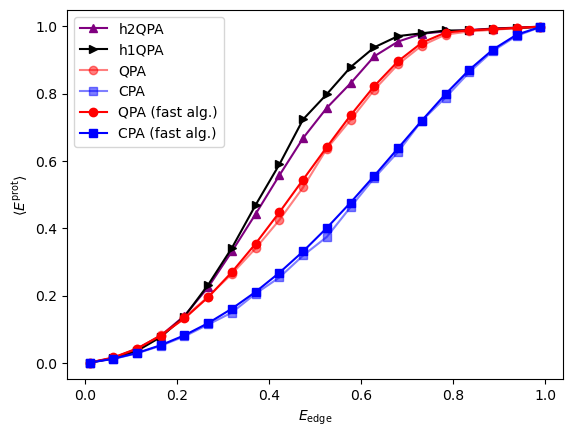

In [22]:
plt.plot(data_h2qep[:, 0], data_h2qep[:, 1], color = 'purple', marker = '^', label = 'h2QPA')
plt.plot(data_hqep[:, 0], data_hqep[:, 1], color = 'black', marker = '>', label = 'h1QPA')
plt.plot(data_qep[:, 0], data_qep[:, 1], color = 'red', marker = 'o', label = 'QPA', alpha = 0.5)
plt.plot(data_cep[:, 0], data_cep[:, 1], color = 'blue', marker = 's', label = 'CPA', alpha = 0.5)

plt.plot(data_qep_fast[:, 0], data_qep_fast[:, 1], color = 'red', marker = 'o', label = 'QPA (fast alg.)')
plt.plot(data_cep_fast[:, 0], data_cep_fast[:, 1], color = 'blue', marker = 's', label = 'CPA (fast alg.)')


plt.xlabel('$E_{\\mathrm{edge}}$')
plt.ylabel('$\\langle E^{\\mathrm{prot}} \\rangle$')

plt.legend(loc = 'upper left')

# Phase diagram

The same diagrams as above are generated using our C implementation. The latter requires to be compiled, see cell below.

In [23]:
# ##compilation needed!
%cd Code
!make
%cd ..

/home/pippo/Dropbox/Personal/Quantum/SPP_Quantum/NEW/Python/RefinedVersion/Code
/home/pippo/anaconda3/bin/x86_64-conda-linux-gnu-cc -ffast-math -O3 -I./ -c ./unweighted_quantum_percolation.c
/home/pippo/anaconda3/bin/x86_64-conda-linux-gnu-cc -ffast-math -O3 -I./ -c ./mt19937-64.c
/home/pippo/anaconda3/bin/x86_64-conda-linux-gnu-cc -ffast-math -O3 -I./ -c ./network_functions.c
/home/pippo/anaconda3/bin/x86_64-conda-linux-gnu-cc -ffast-math -O3 -I./ -c ./quantum_perc_functions.c
/home/pippo/anaconda3/bin/x86_64-conda-linux-gnu-cc unweighted_quantum_percolation.o mt19937-64.o network_functions.o quantum_perc_functions.o -lm -o unweighted_quantum_percolation.out
rm *.o
/home/pippo/Dropbox/Personal/Quantum/SPP_Quantum/NEW/Python/RefinedVersion


The C implementation is run as follows:

./unweighted_quantum_percolation.out netfile W P pt md

* netfile is the file containing the list of edges of the network
* $W \in [1/2, 1]$ is the weight value associated to each edge
* $P>0$ is the total number of node pairs randomly selected to estimate the average entanglement of the protocol
* $pt = 1, 2$ defines the type of protocol considered. $pt = 1$ for QPA and $pt =2$ for CPA
* $md = 0, 1, 2$ defines the diameter of the communication neighborhood. $md = 0$ for standard QPA or CPA, $md = 1$ for h1QPA, $md = 2$ for h2QPA.

One can also set $md = 3$. In such a case, the other parameter values are ingnored, and the algorithm provides a fast estimation for the protocols CPA and QPA by listing the length of all edge-disjoint paths between  $P$ randomly selected pair of nodes.

In [24]:
data_h2qep_c_prog, data_hqep_c_prog, data_qep_c_prog, data_cep_c_prog = [], [], [], []

for ent in np.linspace(0.01, 0.99, 20):
    w = 1.0 - 0.5* ent
    ###
    command = 'Code/unweighted_quantum_percolation.out ' + netfile + ' ' + str(w) + ' ' + str(P) + ' 1 0'
    process = subprocess.Popen(shlex.split(command), stdout=subprocess.PIPE,stderr=subprocess.PIPE)    
    output = process.communicate()[0].decode("utf-8")
    data_qep_c_prog.append([ent, float(output.strip().split('\n')[-1].split()[0])])
    ###
    command = 'Code/unweighted_quantum_percolation.out ' + netfile + ' ' + str(w) + ' ' + str(P) + ' 2 0'
    process = subprocess.Popen(shlex.split(command), stdout=subprocess.PIPE,stderr=subprocess.PIPE)    
    output = process.communicate()[0].decode("utf-8")
    data_cep_c_prog.append([ent, float(output.strip().split('\n')[-1].split()[0])])
    ###
    command = 'Code/unweighted_quantum_percolation.out ' + netfile + ' ' + str(w) + ' ' + str(P) + ' 1 1'
    process = subprocess.Popen(shlex.split(command), stdout=subprocess.PIPE,stderr=subprocess.PIPE)    
    output = process.communicate()[0].decode("utf-8")
    data_hqep_c_prog.append([ent, float(output.strip().split('\n')[-1].split()[0])])
    ###
    command = 'Code/unweighted_quantum_percolation.out ' + netfile + ' ' + str(w) + ' ' + str(P) + ' 1 2'
    process = subprocess.Popen(shlex.split(command), stdout=subprocess.PIPE,stderr=subprocess.PIPE)    
    output = process.communicate()[0].decode("utf-8")
    data_h2qep_c_prog.append([ent, float(output.strip().split('\n')[-1].split()[0])])
    ###

data_cep_c_prog = np.array(data_cep_c_prog)
data_qep_c_prog = np.array(data_qep_c_prog)
data_hqep_c_prog = np.array(data_hqep_c_prog)
data_h2qep_c_prog = np.array(data_h2qep_c_prog)

In [25]:
command = 'Code/unweighted_quantum_percolation.out ' + netfile + ' 0.999 ' + str(P) + ' 1 3 '
print ('#', command)
process = subprocess.Popen(shlex.split(command), stdout=subprocess.PIPE,stderr=subprocess.PIPE)    
output = process.communicate()[0].decode("utf-8")

data_c_prog = []
for line in output.split('\n'):
    if '#' not in line:
        data_c_prog.append([int(num) for num in line.split()])


data_qep_fast_c_prog = quantum_functions.generate_diagram (data_c_prog, 1, 0.01, 0.99, 20)
data_cep_fast_c_prog = quantum_functions.generate_diagram (data_c_prog, 2, 0.01, 0.99, 20)

# Code/unweighted_quantum_percolation.out NetworkData/karate_club.net 0.999 1000 1 3 


In [26]:
print ('AUC h2QPA (C prog.) ', quantum_functions.measure_auc_entanglement(data_h2qep_c_prog))
print ('AUC hQPA (C prog.) ', quantum_functions.measure_auc_entanglement(data_hqep_c_prog))
print ('AUC QPA (C prog.) ', quantum_functions.measure_auc_entanglement(data_qep_c_prog))
print ('AUC CPA (C prog.) ', quantum_functions.measure_auc_entanglement(data_cep_c_prog))
print ('AUC QPA (fast alg., C prog.) ', quantum_functions.measure_auc_entanglement(data_qep_fast_c_prog))
print ('AUC CPA (fast alg., C prog.) ', quantum_functions.measure_auc_entanglement(data_cep_fast_c_prog))

AUC h2QPA (C prog.)  0.5997843070500001
AUC hQPA (C prog.)  0.611236245273684
AUC QPA (C prog.)  0.5521043892447369
AUC CPA (C prog.)  0.42274434470789485
AUC QPA (fast alg., C prog.)  0.5518011468974303
AUC CPA (fast alg., C prog.)  0.42589412398463067


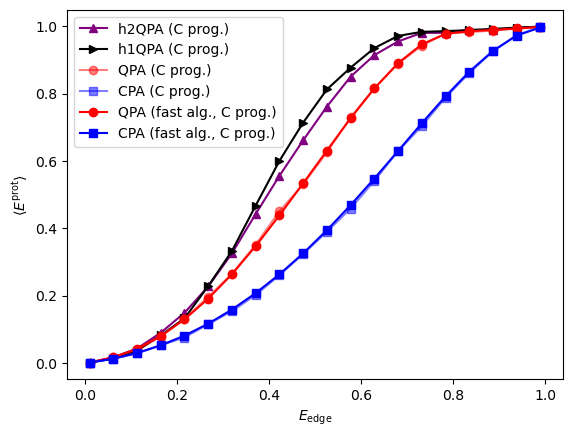

In [28]:
# plt.plot(data_h2qep[:, 0], data_h2qep[:, 1], color = 'purple', marker = '^', label = 'h2QEP')
plt.plot(data_h2qep_c_prog[:, 0], data_h2qep_c_prog[:, 1], color = 'purple', marker = '^', label = 'h2QPA (C prog.)')


# plt.plot(data_hqep[:, 0], data_hqep[:, 1], color = 'black', marker = '>', label = 'hQEP')
plt.plot(data_hqep_c_prog[:, 0], data_hqep_c_prog[:, 1], color = 'black', marker = '>', label = 'h1QPA (C prog.)')

# plt.plot(data_qep[:, 0], data_qep[:, 1], color = 'red', marker = 'o', label = 'QEP', alpha = 0.5)
# plt.plot(data_cep[:, 0], data_cep[:, 1], color = 'blue', marker = 's', label = 'CEP', alpha = 0.5)

plt.plot(data_qep_c_prog[:, 0], data_qep_c_prog[:, 1], color = 'red', marker = 'o', label = 'QPA (C prog.)', alpha = 0.5)
plt.plot(data_cep_c_prog[:, 0], data_cep_c_prog[:, 1], color = 'blue', marker = 's', label = 'CPA (C prog.)', alpha = 0.5)



# plt.plot(data_qep_fast[:, 0], data_qep_fast[:, 1], color = 'red', marker = 'o', label = 'QEP (fast alg.)')
# plt.plot(data_cep_fast[:, 0], data_cep_fast[:, 1], color = 'blue', marker = 's', label = 'CEP (fast alg.)')

plt.plot(data_qep_fast_c_prog[:, 0], data_qep_fast_c_prog[:, 1], color = 'red', marker = 'o', label = 'QPA (fast alg., C prog.)')
plt.plot(data_cep_fast_c_prog[:, 0], data_cep_fast_c_prog[:, 1], color = 'blue', marker = 's', label = 'CPA (fast alg., C prog.)')


plt.xlabel('$E_{\\mathrm{edge}}$')
plt.ylabel('$\\langle E^{\\mathrm{prot}} \\rangle$')


plt.legend(loc = 'upper left')

## Final consistency test

Only to test the consistency of the Python and C implementations, we generate phase diagrams using the hCEP protocol.

In [29]:
data_hcep, data_h2cep = [], []

P = 1000
for ent in np.linspace(0.01, 0.99, 20):

    w = 1.0 - 0.5* ent
    
    results_hcep = quantum_functions.quantum_percolation_refined (G, P, w, 2, 1)
    summary_hcep = quantum_functions.summarize_results_refined (results_hcep, 2)
    data_hcep.append([ent, summary_hcep[0]])

    results_h2cep = quantum_functions.quantum_percolation_refined (G, P, w, 2, 2)
    summary_h2cep = quantum_functions.summarize_results_refined (results_h2cep, 2)
    data_h2cep.append([ent, summary_h2cep[0]])
    
data_hcep = np.array(data_hcep)
data_h2cep = np.array(data_h2cep)

In [30]:
data_hcep_c_prog, data_h2cep_c_prog = [], []

for ent in np.linspace(0.01, 0.99, 20):
    w = 1.0 - 0.5* ent
    ###
    command = 'Code/unweighted_quantum_percolation.out ' + netfile + ' ' + str(w) + ' ' + str(P) + ' 2 1'
    process = subprocess.Popen(shlex.split(command), stdout=subprocess.PIPE,stderr=subprocess.PIPE)    
    output = process.communicate()[0].decode("utf-8")
    data_hcep_c_prog.append([ent, float(output.strip().split('\n')[-1].split()[0])])
    ###
    command = 'Code/unweighted_quantum_percolation.out ' + netfile + ' ' + str(w) + ' ' + str(P) + ' 2 2'
    process = subprocess.Popen(shlex.split(command), stdout=subprocess.PIPE,stderr=subprocess.PIPE)    
    output = process.communicate()[0].decode("utf-8")
    data_h2cep_c_prog.append([ent, float(output.strip().split('\n')[-1].split()[0])])
    

data_hcep_c_prog = np.array(data_hcep_c_prog)
data_h2cep_c_prog = np.array(data_h2cep_c_prog)

In [31]:
print ('AUC h2CPA (Python) ', quantum_functions.measure_auc_entanglement(data_h2cep))
print ('AUC h2CPA (C prog.) ', quantum_functions.measure_auc_entanglement(data_h2cep_c_prog))
print ('AUC h1CPA (Python) ', quantum_functions.measure_auc_entanglement(data_hcep))
print ('AUC h1CPA (C prog.) ', quantum_functions.measure_auc_entanglement(data_hcep_c_prog))

AUC h2CPA (Python)  0.46376374627246136
AUC h2CPA (C prog.)  0.4641341138947368
AUC h1CPA (Python)  0.44482329694605044
AUC h1CPA (C prog.)  0.44604657968157907


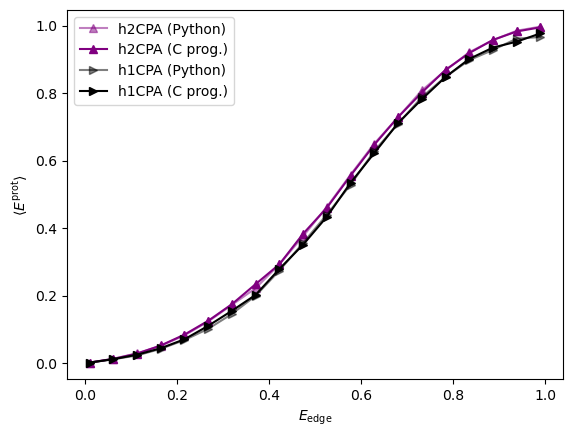

In [32]:
plt.plot(data_h2cep[:, 0], data_h2cep[:, 1], color = 'purple', marker = '^', label = 'h2CPA (Python)', alpha = 0.5)
plt.plot(data_h2cep_c_prog[:, 0], data_h2cep_c_prog[:, 1], color = 'purple', marker = '^', label = 'h2CPA (C prog.)')


plt.plot(data_hcep[:, 0], data_hcep[:, 1], color = 'black', marker = '>', label = 'h1CPA (Python)', alpha = 0.5)
plt.plot(data_hcep_c_prog[:, 0], data_hcep_c_prog[:, 1], color = 'black', marker = '>', label = 'h1CPA (C prog.)')

plt.xlabel('$E_{\\mathrm{edge}}$')
plt.ylabel('$\\langle E^{\\mathrm{prot}} \\rangle$')

plt.legend(loc = 'upper left')